In [22]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import os
import warnings
warnings.filterwarnings('ignore')

# Load data
file_path = r"C:\Users\jdelhoyo\PhD\Study cases\Genissiat\Arve-Valserine\Isotopes\GitHub Isotopes\Data\SorgesData.xlsx"
df = pd.read_excel(file_path)

print(f"Data loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst rows:\n{df.head()}")

Data loaded: (370, 55)
Columns: ['Sample', 'D', 'O', 'Sp', 'Cond', 'Order', 'Year', 'Unnamed: 7', 'Unnamed: 8', 'Conditions Total', 'Unnamed: 10', 'MeanO', 'MeanH', 'Error O', 'Error H', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54']

First rows:
   Sample           D          O        Sp    Cond  Order  Year  Unnamed: 7  \
0  S-FO-1  -98.797599  24.340408  Fraxinus  Living      0     1         NaN   
1  S-FO-2  -95.081829  22.504079  Fraxinus

In [23]:
# Explore data categories
print("Unique species:")
print(df['Sp'].unique())
print(f"\nSpecies counts:\n{df['Sp'].value_counts()}")

print("\n" + "="*50)
print("Unique conditions:")
print(df['Cond'].unique())
print(f"\nCondition counts:\n{df['Cond'].value_counts()}")

print("\n" + "="*50)
print("Species x Condition crosstab:")
print(pd.crosstab(df['Sp'], df['Cond']))

Unique species:
['Fraxinus' 'Alnus']

Species counts:
Sp
Alnus       190
Fraxinus    180
Name: count, dtype: int64

Unique conditions:
['Living' 'Float' 'Out' 'Sub']

Condition counts:
Cond
Out       160
Float     150
Sub        40
Living     20
Name: count, dtype: int64

Species x Condition crosstab:
Cond      Float  Living  Out  Sub
Sp                               
Alnus        80      10   80   20
Fraxinus     70      10   80   20


In [24]:
# Create 6 groups: Sp (Fraxinus, Alnus) + Living + Condition (Float, Out, Sub)
grupos = {
    'Fraxinus_Living_Float': df[(df['Sp'] == 'Fraxinus') & (df['Cond'].isin(['Living', 'Float']))],
    'Fraxinus_Living_Out': df[(df['Sp'] == 'Fraxinus') & (df['Cond'].isin(['Living', 'Out']))],
    'Fraxinus_Living_Sub': df[(df['Sp'] == 'Fraxinus') & (df['Cond'].isin(['Living', 'Sub']))],
    'Alnus_Living_Float': df[(df['Sp'] == 'Alnus') & (df['Cond'].isin(['Living', 'Float']))],
    'Alnus_Living_Out': df[(df['Sp'] == 'Alnus') & (df['Cond'].isin(['Living', 'Out']))],
    'Alnus_Living_Sub': df[(df['Sp'] == 'Alnus') & (df['Cond'].isin(['Living', 'Sub']))]
}

print("\n" + "="*70)
print("6 GROUPS CREATED")
print("="*70)

for nombre, grupo_df in grupos.items():
    print(f"\n{nombre}: {len(grupo_df)} samples")
    print(f"  D: {grupo_df['D'].mean():.2f} ± {grupo_df['D'].std():.2f}")
    print(f"  O: {grupo_df['O'].mean():.2f} ± {grupo_df['O'].std():.2f}")


6 GROUPS CREATED

Fraxinus_Living_Float: 80 samples
  D: -87.61 ± 9.30
  O: 22.14 ± 1.48

Fraxinus_Living_Out: 90 samples
  D: -93.13 ± 9.36
  O: 22.26 ± 1.30

Fraxinus_Living_Sub: 30 samples
  D: -88.06 ± 10.41
  O: 23.63 ± 1.82

Alnus_Living_Float: 90 samples
  D: -101.04 ± 4.73
  O: 21.33 ± 0.94

Alnus_Living_Out: 90 samples
  D: -103.48 ± 6.04
  O: 20.69 ± 1.49

Alnus_Living_Sub: 30 samples
  D: -105.57 ± 5.57
  O: 21.80 ± 1.01


In [25]:
# Mann-Kendall test for each group
print("\n" + "="*100)
print("MANN-KENDALL TEST: ONE TEST PER GROUP")
print("="*100)

mk_results = {}

for nombre_grupo, grupo_df in grupos.items():
    print(f"\n{nombre_grupo}:")
    
    # Calculate mean D and O for each Order
    time_series = grupo_df.groupby('Order')[['D', 'O']].mean().reset_index().sort_values('Order')
    time_points = time_series['Order'].values
    mean_d = time_series['D'].values
    mean_o = time_series['O'].values
    n_timepoints = len(time_series)
    
    print(f"  Time points: {n_timepoints} Orders")
    print(f"  Orders: {sorted([int(x) for x in time_points])}")
    
    # Apply Mann-Kendall test
    time_indices = np.arange(n_timepoints)
    tau_d, p_d = kendalltau(time_indices, mean_d)
    tau_o, p_o = kendalltau(time_indices, mean_o)
    
    trend_d = "Increasing" if tau_d > 0 else "Decreasing"
    sig_d = "***" if p_d < 0.05 else "NS"
    trend_o = "Increasing" if tau_o > 0 else "Decreasing"
    sig_o = "***" if p_o < 0.05 else "NS"
    
    print(f"  D: τ={tau_d:.4f}, p={p_d:.4f} ({trend_d}, {sig_d})")
    print(f"  O: τ={tau_o:.4f}, p={p_o:.4f} ({trend_o}, {sig_o})")
    
    mk_results[nombre_grupo] = {
        'n_timepoints': n_timepoints,
        'D_tau': tau_d, 'D_pval': p_d, 'D_trend': trend_d,
        'O_tau': tau_o, 'O_pval': p_o, 'O_trend': trend_o
    }


MANN-KENDALL TEST: ONE TEST PER GROUP

Fraxinus_Living_Float:
  Time points: 8 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7]
  D: τ=0.1429, p=0.7195 (Increasing, NS)
  O: τ=-0.7143, p=0.0141 (Decreasing, ***)

Fraxinus_Living_Out:
  Time points: 9 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  D: τ=-0.0556, p=0.9195 (Decreasing, NS)
  O: τ=-0.6667, p=0.0127 (Decreasing, ***)

Fraxinus_Living_Sub:
  Time points: 3 Orders
  Orders: [0, 1, 3]
  D: τ=0.3333, p=1.0000 (Increasing, NS)
  O: τ=-0.3333, p=1.0000 (Decreasing, NS)

Alnus_Living_Float:
  Time points: 9 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  D: τ=0.0556, p=0.9195 (Increasing, NS)
  O: τ=-0.3333, p=0.2595 (Decreasing, NS)

Alnus_Living_Out:
  Time points: 9 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  D: τ=-0.2222, p=0.4767 (Decreasing, NS)
  O: τ=-0.7222, p=0.0059 (Decreasing, ***)

Alnus_Living_Sub:
  Time points: 3 Orders
  Orders: [0, 1, 3]
  D: τ=-0.3333, p=1.0000 (Decreasing, NS)
  O: τ=-0.3333, p=1.0000 (Decreasing, N

In [26]:
# Descriptive statistics: mean and std by Order for each group
print("\n" + "="*100)
print("DESCRIPTIVE STATISTICS: MEAN AND STD BY ORDER")
print("="*100)

descriptive_stats = {}

for nombre_grupo, grupo_df in grupos.items():
    print(f"\n{nombre_grupo}:")
    
    stats_by_order = grupo_df.groupby('Order')[['D', 'O']].agg(['mean', 'std', 'count']).reset_index().sort_values('Order')
    stats_by_order.columns = ['Order', 'D_mean', 'D_std', 'D_count', 'O_mean', 'O_std', 'O_count']
    
    print(f"{'Order':<8} {'N':<6} {'D_mean':<14} {'D_std':<14} {'O_mean':<14} {'O_std':<14}")
    for idx, row in stats_by_order.iterrows():
        print(f"{int(row['Order']):<8} {int(row['D_count']):<6} {row['D_mean']:<14.4f} {row['D_std']:<14.4f} {row['O_mean']:<14.4f} {row['O_std']:<14.4f}")
    
    descriptive_stats[nombre_grupo] = stats_by_order


DESCRIPTIVE STATISTICS: MEAN AND STD BY ORDER

Fraxinus_Living_Float:
Order    N      D_mean         D_std          O_mean         O_std         
0        10     -99.3528       6.0812         23.8422        0.9612        
1        10     -81.6943       5.9972         23.2698        1.7349        
2        10     -90.3725       6.7717         21.8207        0.7377        
3        10     -84.0564       5.4691         22.1749        0.7806        
4        10     -84.8751       6.6413         22.1702        0.9090        
5        9      -92.2351       8.2363         20.6149        1.0292        
6        10     -86.6529       6.4621         21.5939        0.9833        
7        10     -82.1368       13.2829        21.4972        1.7954        

Fraxinus_Living_Out:
Order    N      D_mean         D_std          O_mean         O_std         
0        10     -99.3528       6.0812         23.8422        0.9612        
1        10     -87.1830       5.4178         23.8580        1.1834    

In [27]:
# Group-level extremes: find max/min for each group and calculate deviations
print("\n" + "="*100)
print("GROUP-LEVEL EXTREMES ANALYSIS")
print("="*100)

group_extremes = {}

for nombre_grupo, grupo_df in grupos.items():
    print(f"\n{nombre_grupo}:")
    
    # Get time series for this group
    time_series = grupo_df.groupby('Order')[['D', 'O']].mean().reset_index().sort_values('Order')
    mean_d_values = time_series['D'].values
    mean_o_values = time_series['O'].values
    orders = time_series['Order'].values
    
    # Get baseline (Order 0)
    baseline_d = time_series[time_series['Order'] == 0]['D'].values[0]
    baseline_o = time_series[time_series['Order'] == 0]['O'].values[0]
    
    print(f"  Baseline (Order 0): D={baseline_d:.4f}, O={baseline_o:.4f}")
    
    # Find extremes
    max_d_idx = np.argmax(mean_d_values)
    min_d_idx = np.argmin(mean_d_values)
    max_o_idx = np.argmax(mean_o_values)
    min_o_idx = np.argmin(mean_o_values)
    
    max_d_val = mean_d_values[max_d_idx]
    max_d_ord = int(orders[max_d_idx])
    max_d_dev = max_d_val - baseline_d
    
    min_d_val = mean_d_values[min_d_idx]
    min_d_ord = int(orders[min_d_idx])
    min_d_dev = min_d_val - baseline_d
    
    max_o_val = mean_o_values[max_o_idx]
    max_o_ord = int(orders[max_o_idx])
    max_o_dev = max_o_val - baseline_o
    
    min_o_val = mean_o_values[min_o_idx]
    min_o_ord = int(orders[min_o_idx])
    min_o_dev = min_o_val - baseline_o
    
    print(f"  D MAX: Order {max_d_ord}, Value={max_d_val:.4f}, Deviation={max_d_dev:+.4f}")
    print(f"  D MIN: Order {min_d_ord}, Value={min_d_val:.4f}, Deviation={min_d_dev:+.4f}")
    print(f"  O MAX: Order {max_o_ord}, Value={max_o_val:.4f}, Deviation={max_o_dev:+.4f}")
    print(f"  O MIN: Order {min_o_ord}, Value={min_o_val:.4f}, Deviation={min_o_dev:+.4f}")
    
    group_extremes[nombre_grupo] = {
        'Baseline_D': baseline_d, 'Baseline_O': baseline_o,
        'Max_D_val': max_d_val, 'Max_D_ord': max_d_ord, 'Max_D_dev': max_d_dev,
        'Min_D_val': min_d_val, 'Min_D_ord': min_d_ord, 'Min_D_dev': min_d_dev,
        'Max_O_val': max_o_val, 'Max_O_ord': max_o_ord, 'Max_O_dev': max_o_dev,
        'Min_O_val': min_o_val, 'Min_O_ord': min_o_ord, 'Min_O_dev': min_o_dev
    }


GROUP-LEVEL EXTREMES ANALYSIS

Fraxinus_Living_Float:
  Baseline (Order 0): D=-99.3528, O=23.8422
  D MAX: Order 1, Value=-81.6943, Deviation=+17.6586
  D MIN: Order 0, Value=-99.3528, Deviation=+0.0000
  O MAX: Order 0, Value=23.8422, Deviation=+0.0000
  O MIN: Order 5, Value=20.6149, Deviation=-3.2273

Fraxinus_Living_Out:
  Baseline (Order 0): D=-99.3528, O=23.8422
  D MAX: Order 2, Value=-81.3664, Deviation=+17.9864
  D MIN: Order 8, Value=-101.3509, Deviation=-1.9980
  O MAX: Order 1, Value=23.8580, Deviation=+0.0158
  O MIN: Order 7, Value=21.4395, Deviation=-2.4026

Fraxinus_Living_Sub:
  Baseline (Order 0): D=-99.3528, O=23.8422
  D MAX: Order 1, Value=-81.8407, Deviation=+17.5122
  D MIN: Order 0, Value=-99.3528, Deviation=+0.0000
  O MAX: Order 1, Value=24.5264, Deviation=+0.6842
  O MIN: Order 3, Value=22.5291, Deviation=-1.3131

Alnus_Living_Float:
  Baseline (Order 0): D=-102.5445, O=21.7779
  D MAX: Order 3, Value=-95.6276, Deviation=+6.9170
  D MIN: Order 5, Value=-104.

In [28]:
# Export all results to Excel
output_dir = r"C:\Users\jdelhoyo\PhD\Study cases\Genissiat\Arve-Valserine\Isotopes\GitHub Isotopes\Results"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*100)
print("EXPORTING RESULTS TO EXCEL")
print("="*100)

# 1. Mann-Kendall results
mk_data = []
for nombre, result in mk_results.items():
    mk_data.append({
        'Group': nombre, 'Variable': 'D', 'N': result['n_timepoints'],
        'Kendall_tau': result['D_tau'], 'p_value': result['D_pval'], 'Trend': result['D_trend']
    })
    mk_data.append({
        'Group': nombre, 'Variable': 'O', 'N': result['n_timepoints'],
        'Kendall_tau': result['O_tau'], 'p_value': result['O_pval'], 'Trend': result['O_trend']
    })
mk_df = pd.DataFrame(mk_data)

# 2. Group extremes
extreme_data = []
for nombre, result in group_extremes.items():
    extreme_data.append({
        'Group': nombre, 'Variable': 'D', 'Type': 'MAX',
        'Value': result['Max_D_val'], 'Order': result['Max_D_ord'], 'Deviation': result['Max_D_dev']
    })
    extreme_data.append({
        'Group': nombre, 'Variable': 'D', 'Type': 'MIN',
        'Value': result['Min_D_val'], 'Order': result['Min_D_ord'], 'Deviation': result['Min_D_dev']
    })
    extreme_data.append({
        'Group': nombre, 'Variable': 'O', 'Type': 'MAX',
        'Value': result['Max_O_val'], 'Order': result['Max_O_ord'], 'Deviation': result['Max_O_dev']
    })
    extreme_data.append({
        'Group': nombre, 'Variable': 'O', 'Type': 'MIN',
        'Value': result['Min_O_val'], 'Order': result['Min_O_ord'], 'Deviation': result['Min_O_dev']
    })
extreme_df = pd.DataFrame(extreme_data)

# Write to Excel with multiple sheets
with pd.ExcelWriter(os.path.join(output_dir, 'Isotope_Analysis_Complete2.xlsx'), engine='openpyxl') as writer:
    mk_df.to_excel(writer, sheet_name='Mann-Kendall', index=False)
    extreme_df.to_excel(writer, sheet_name='Group-Extremes', index=False)
    for nombre, stats_df in descriptive_stats.items():
        sheet_name = nombre[:31]  # Excel limit
        stats_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"\n✓ File saved: {os.path.join(output_dir, 'Isotope_Analysis_Complete2.xlsx')}")
print("\nSheets created:")
print("  1. Mann-Kendall: Test results for each group")
print("  2. Group-Extremes: Max/min values and deviations for each group")
print(f"  3-8. Group statistics: Descriptive stats by Order for each group")


EXPORTING RESULTS TO EXCEL

✓ File saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\Arve-Valserine\Isotopes\GitHub Isotopes\Results\Isotope_Analysis_Complete2.xlsx

Sheets created:
  1. Mann-Kendall: Test results for each group
  2. Group-Extremes: Max/min values and deviations for each group
  3-8. Group statistics: Descriptive stats by Order for each group



Fraxinus:
  Float: n=70, δD=-85.91±8.44‰, δ¹⁸O=21.90±1.38‰
  Out: n=80, δD=-92.35±9.43‰, δ¹⁸O=22.07±1.20‰
  Sub: n=20, δD=-82.41±6.88‰, δ¹⁸O=23.53±2.14‰
  Living: n=10, δD=-99.35±6.08‰, δ¹⁸O=23.84±0.96‰

Alnus:
  Float: n=80, δD=-100.85±4.82‰, δ¹⁸O=21.28±0.96‰
  Out: n=80, δD=-103.60±6.28‰, δ¹⁸O=20.56±1.51‰
  Sub: n=20, δD=-107.08±5.77‰, δ¹⁸O=21.82±1.15‰
  Living: n=10, δD=-102.54±3.78‰, δ¹⁸O=21.78±0.69‰


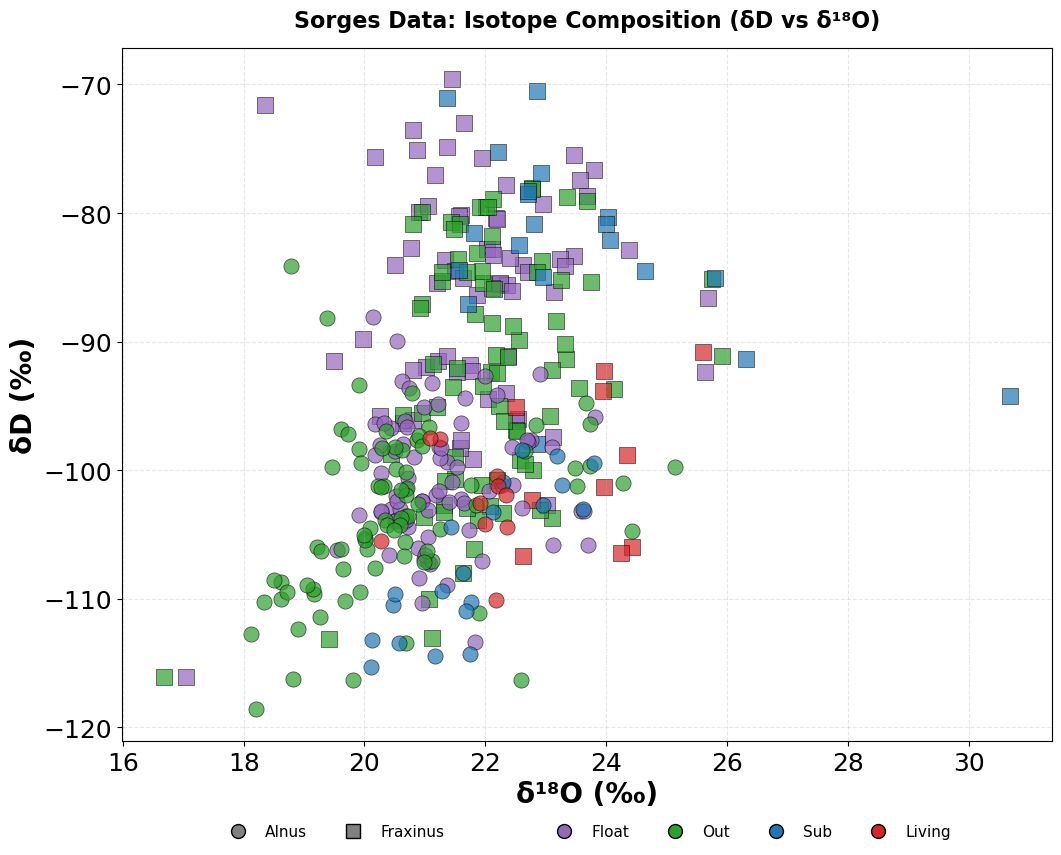

In [34]:
import matplotlib.pyplot as plt

# Define color mapping for conditions
condition_colors = {
    'Float': '#9467bd',  # Purple
    'Out': '#2ca02c',    # Green
    'Sub': '#1f77b4',    # Blue
    'Living': '#d62728'  # Red
}

# Define marker styles for species
marker_styles = {
    'Alnus': 'o',        # Circle
    'Fraxinus': 's'      # Square
}

# Create figure with single plot
fig, ax = plt.subplots(figsize=(12, 9))

# Plot data for each species and condition combination
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        
        if len(condition_data) > 0:
            ax.scatter(condition_data['O'], condition_data['D'], 
                      marker=marker_styles[species], s=120, 
                      c=condition_colors[condition], 
                      alpha=0.7, edgecolors='black', linewidth=0.5)

# Formatting
ax.set_xlabel('δ¹⁸O (‰)', fontsize=20, fontweight='bold')
ax.set_ylabel('δD (‰)', fontsize=20, fontweight='bold')
ax.set_title('Sorges Data: Isotope Composition (δD vs δ¹⁸O)', fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid(True, alpha=0.3, linestyle='--')

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []

# Add species markers
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Alnus', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Fraxinus', markeredgecolor='black'))

legend_elements.append(Line2D([0], [0], color='none', label=''))  # Empty line for spacing

# Add condition colors
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#9467bd', markersize=10, label='Float', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=10, label='Out', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=10, label='Sub', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Living', markeredgecolor='black'))

ax.legend(handles=legend_elements, fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=7, frameon=False)
print(f"{'='*60}")
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    print(f"\n{species}:")
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        if len(condition_data) > 0:
            print(f"  {condition}: n={len(condition_data)}, δD={condition_data['D'].mean():.2f}±{condition_data['D'].std():.2f}‰, δ¹⁸O={condition_data['O'].mean():.2f}±{condition_data['O'].std():.2f}‰")

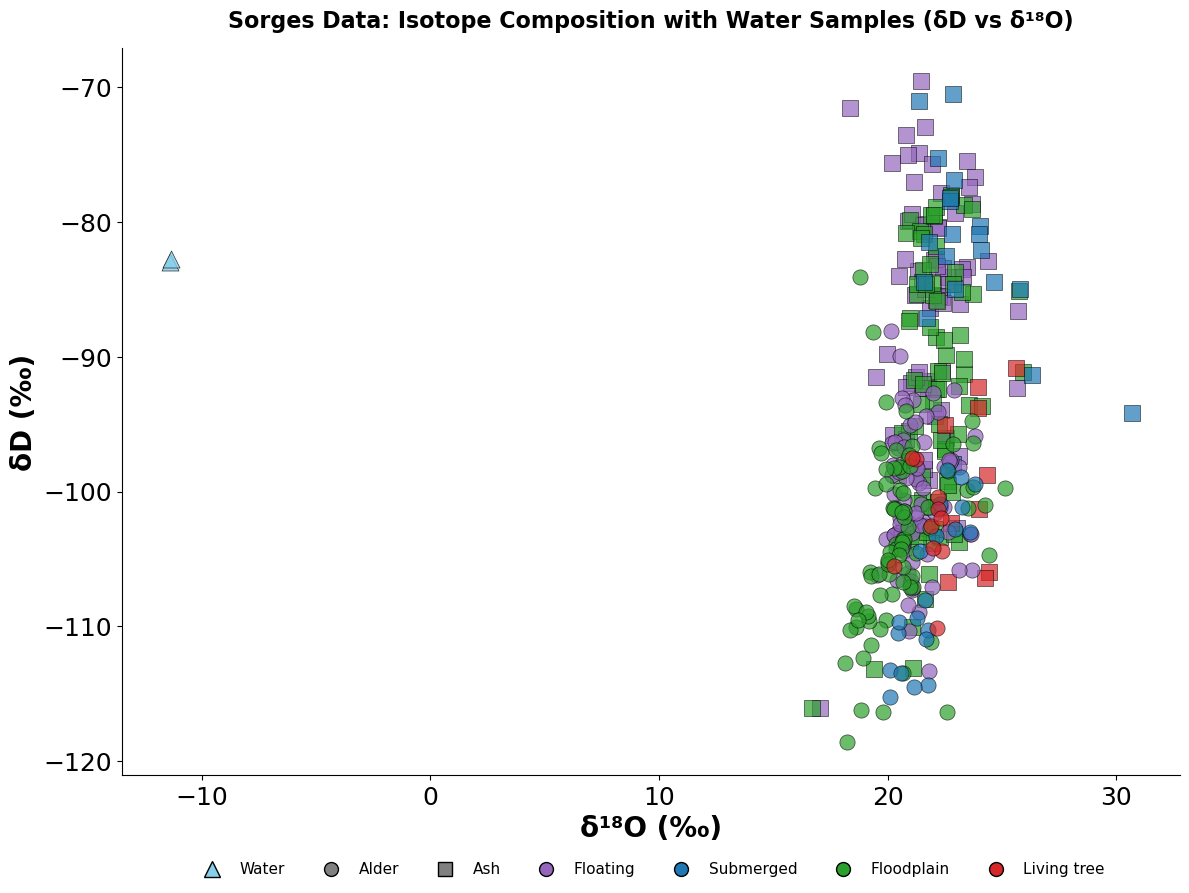


Isotope Scatter Plot with Water Samples - Summary

Fraxinus:
  Float: n=70, δD=-85.91±8.44‰, δ¹⁸O=21.90±1.38‰
  Out: n=80, δD=-92.35±9.43‰, δ¹⁸O=22.07±1.20‰
  Sub: n=20, δD=-82.41±6.88‰, δ¹⁸O=23.53±2.14‰
  Living: n=10, δD=-99.35±6.08‰, δ¹⁸O=23.84±0.96‰

Alnus:
  Float: n=80, δD=-100.85±4.82‰, δ¹⁸O=21.28±0.96‰
  Out: n=80, δD=-103.60±6.28‰, δ¹⁸O=20.56±1.51‰
  Sub: n=20, δD=-107.08±5.77‰, δ¹⁸O=21.82±1.15‰
  Living: n=10, δD=-102.54±3.78‰, δ¹⁸O=21.78±0.69‰

Water Samples:
  Sorges-M.1: δ¹⁸O=-11.39‰, δD=-83.00‰
  Sorges-M.2: δ¹⁸O=-11.33‰, δD=-82.80‰


In [32]:
import matplotlib.pyplot as plt

# Define color mapping for conditions
condition_colors = {
    'Float': '#9467bd',  # Purple
    'Out': '#2ca02c',    # Green
    'Sub': '#1f77b4',    # Blue
    'Living': '#d62728'  # Red
}

# Define marker styles for species
marker_styles = {
    'Alnus': 'o',        # Circle
    'Fraxinus': 's'      # Square
}

# Water samples data
water_samples = [
    {'name': 'Sorges-M.1', 'O': -11.39, 'D': -83.0},
    {'name': 'Sorges-M.2', 'O': -11.33, 'D': -82.8}
]

# Create figure with single plot
fig, ax = plt.subplots(figsize=(12, 9))

# Plot data for each species and condition combination
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        
        if len(condition_data) > 0:
            ax.scatter(condition_data['O'], condition_data['D'], 
                      marker=marker_styles[species], s=120, 
                      c=condition_colors[condition], 
                      alpha=0.7, edgecolors='black', linewidth=0.5)

# Plot water samples
water_o = [sample['O'] for sample in water_samples]
water_d = [sample['D'] for sample in water_samples]
ax.scatter(water_o, water_d, 
          marker='^', s=150, 
          c='#87CEEB',  # Light blue
          label='Water', 
          alpha=0.8, edgecolors='black', linewidth=0.5)

# Formatting
ax.set_xlabel('δ¹⁸O (‰)', fontsize=20, fontweight='bold')
ax.set_ylabel('δD (‰)', fontsize=20, fontweight='bold')
ax.set_title('Sorges Data: Isotope Composition with Water Samples (δD vs δ¹⁸O)', fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []

# Add water marker first
legend_elements.append(Line2D([0], [0], marker='^', color='w', markerfacecolor='#87CEEB', markersize=11, label='Water', markeredgecolor='black'))

# Add species markers
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Alder', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Ash', markeredgecolor='black'))

# Add condition colors
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#9467bd', markersize=10, label='Floating', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=10, label='Submerged', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=10, label='Floodplain', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Living tree', markeredgecolor='black'))

ax.legend(handles=legend_elements, fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=8, frameon=False)

plt.tight_layout()
plt.show()

print(f"\nIsotope Scatter Plot with Water Samples - Summary")
print(f"{'='*60}")
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    print(f"\n{species}:")
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        if len(condition_data) > 0:
            print(f"  {condition}: n={len(condition_data)}, δD={condition_data['D'].mean():.2f}±{condition_data['D'].std():.2f}‰, δ¹⁸O={condition_data['O'].mean():.2f}±{condition_data['O'].std():.2f}‰")

print(f"\nWater Samples:")
for sample in water_samples:
    print(f"  {sample['name']}: δ¹⁸O={sample['O']:.2f}‰, δD={sample['D']:.2f}‰")